# Fraud Detection: Hyperparameter Tuning with GridSearchCV

In this notebook, we move beyond baseline weights to systematically find the best hyperparameters for our models using Cross-Validation.

### Objectives:
1. **Tuning XGBoost**: Optimize depth, learning rate, and estimators.
2. **Tuning Random Forest**: Optimize tree complexity.
3. **Cost Re-Optimization**: Find the best threshold for the tuned models.
4. **Comparison**: Check if tuning significantly reduces our business cost.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib

sns.set_theme(style="whitegrid")

## 1. Load Data

In [3]:
X_train = pd.read_csv("artifacts/X_train.csv")
y_train = pd.read_csv("artifacts/y_train.csv").values.ravel()
X_test = pd.read_csv("artifacts/X_test.csv")
y_test = pd.read_csv("artifacts/y_test.csv").values.ravel()

ratio = (len(y_train) - sum(y_train)) / sum(y_train)

## 2. GridSearchCV for XGBoost
We keep `scale_pos_weight` constant to handle imbalance while tuning other structural parameters.

In [4]:
xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

param_grid_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

grid_xgb = GridSearchCV(
    xgb, 
    param_grid_xgb, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

grid_xgb.fit(X_train, y_train)
print(f"Best XGB Params: {grid_xgb.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}


## 3. GridSearchCV for Random Forest

In [5]:
rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)

param_grid_rf = {
    'max_depth': [10, 20, None],
    'n_estimators': [100, 200],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    rf, 
    param_grid_rf, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

grid_rf.fit(X_train, y_train)
print(f"Best RF Params: {grid_rf.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


## 4. Threshold Optimization based on Business Cost

We define a cost function:
1. **Fraud Loss (FN)**: $100 per missed fraud.
2. **False Alarm (FP)**: $5 per investigation cost.

In [6]:
def optimize_threshold(y_true, y_probs, cost_fn=100, cost_fp=5):
    thresholds = np.linspace(0, 1, 101)
    costs = []
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        costs.append((fn * cost_fn) + (fp * cost_fp))
    return thresholds[np.argmin(costs)], np.min(costs)

best_xgb = grid_xgb.best_estimator_
best_rf = grid_rf.best_estimator_

xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

t_xgb, cost_xgb = optimize_threshold(y_test, xgb_probs)
t_rf, cost_rf = optimize_threshold(y_test, rf_probs)

print(f"Tuned XGB Cost: ${cost_xgb:,} at {t_xgb}")
print(f"Tuned RF Cost: ${cost_rf:,} at {t_rf}")

Tuned XGB Cost: $96,515 at 0.38
Tuned RF Cost: $97,025 at 0.09


## 5. Standard Evaluation at Optimal Threshold

--- XGBoost (Threshold: 0.38) ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27393
           1       0.52      0.69      0.59      2830

    accuracy                           0.91     30223
   macro avg       0.74      0.81      0.77     30223
weighted avg       0.92      0.91      0.92     30223



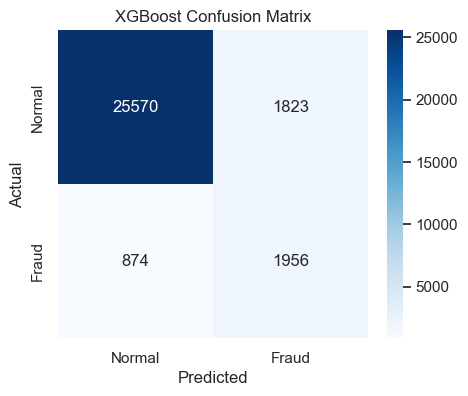

--- Random Forest (Threshold: 0.09) ---
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     27393
           1       0.40      0.71      0.51      2830

    accuracy                           0.87     30223
   macro avg       0.68      0.80      0.72     30223
weighted avg       0.91      0.87      0.89     30223



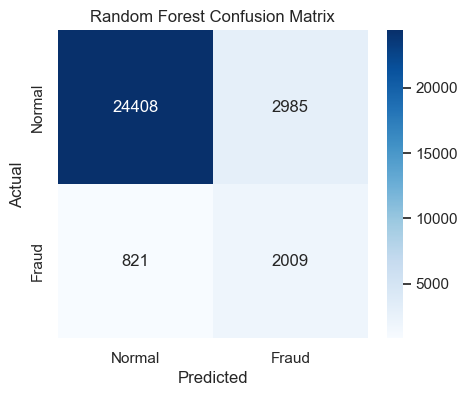

In [ ]:
def evaluate_model(y_true, y_probs, threshold, model_name):
    preds = (y_probs >= threshold).astype(int)
    
    print(f"--- {model_name} (Threshold: {threshold:.2f}) ---")
    print(classification_report(y_true, preds))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(y_test, xgb_probs, t_xgb, "XGBoost")
evaluate_model(y_test, rf_probs, t_rf, "Random Forest")

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix # Often used with these metrics
)

preds = (xgb_probs >= t_xgb).astype(int)


print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall:    {recall_score(y_test, preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, preds):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, xgb_probs):.4f}") 


--- Model Performance Metrics ---
Accuracy:  0.9108
Precision: 0.5176
Recall:    0.6912
F1-Score:  0.5919
ROC AUC:   0.8336


## 6. Save Optimized Models

In [9]:
joblib.dump(best_xgb, "artifacts/models/xgb_tuned_model.joblib")
joblib.dump(best_rf, "artifacts/models/rf_tuned_model.joblib")
print("Tuned models saved.")

Tuned models saved.
